## Artéfact à la YASA

In [26]:
import yasa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white', font_scale=1.2)
import mne
import io


In [33]:

raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)
data = raw.get_data()
chan = raw.ch_names
sfreq = raw.info['sfreq'] 

hypno_path = 'D:/EEG/raw/MN143/MN143_240115E-AhypnoEXP.txt'
hypno_df = pd.read_csv(hypno_path, sep="\t", names=["start", "time", "stage", "code"])

# Convertir les stades texte en code YASA
stage_map = {
    "W": 0, "N1": 1, "N2": 2, "N3": 3, "REM": 4
}

print(f"{data.shape[0]} canaux, {data.shape[1]} points à {sfreq} Hz")
chan
(data*10**6).round(4)

Extracting EDF parameters from D:\EEG\raw\MN143\MN143_240115E-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6855679  =      0.000 ... 26779.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_28464\873819642.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)


33 canaux, 6855680 points à 256.0 Hz


array([[ 8.95000000e-02,  8.95000000e-02,  8.95000000e-02, ...,
         1.25381300e+02,  9.84400000e-01, -8.74358000e+01],
       [ 8.95000000e-02,  8.95000000e-02,  8.95000000e-02, ...,
         1.40416300e+02,  2.80117000e+01, -6.02296000e+01],
       [ 8.95000000e-02,  8.95000000e-02,  8.95000000e-02, ...,
         6.61362000e+01, -5.71868000e+01, -1.48112800e+02],
       ...,
       [ 1.89211870e+03,  1.89211870e+03,  1.89211870e+03, ...,
         3.50988022e+06,  3.51366445e+06,  3.51744869e+06],
       [ 8.94941634e+04,  8.94941634e+04,  8.94941634e+04, ...,
         8.94941634e+04,  8.94941634e+04,  8.94941634e+04],
       [-3.66216500e+02, -3.66216500e+02, -3.66216500e+02, ...,
         1.33669032e+05,  1.32936599e+05,  1.32936599e+05]],
      shape=(33, 6855680))

08-Jul-25 15:55:20 | WARNING | Hypnogram is SHORTER than data by 41796.80 seconds. Padding hypnogram with last value to match data.size.
C:\Users\Dessalines\AppData\Local\Temp\ipykernel_28464\216977945.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


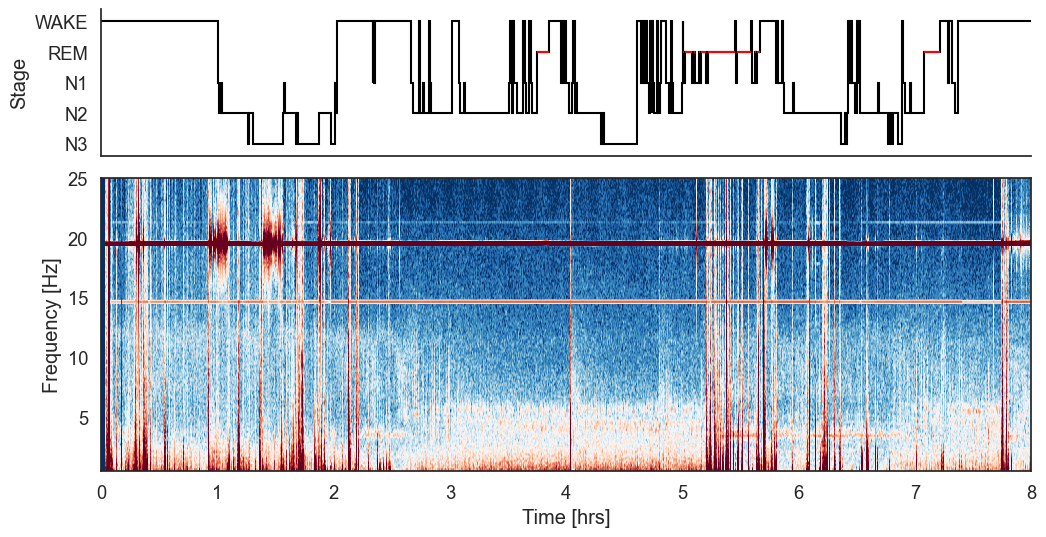

In [ ]:
# Plot hypnogram and spectrogram on Fz
# We should see a warning because of the flat data at the end
sf = 100.
hypno_int = hypno_df["stage"].str.strip().map(stage_map).fillna(-2).astype(int)
hypno_vec = yasa.hypno_upsample_to_data(hypno_int.values, 1/30, data[2], sf)
fig = yasa.plot_spectrogram(data[2], sf, hypno=hypno_vec)

# Récupère les axes de la figure
ax0, ax1 = fig.axes  # ax0 = hypnogram, ax1 = spectrogramme

# Limite d'heure
ax0.set_xlim(0, 8)
ax1.set_xlim(0, 8)

plt.tight_layout()
plt.show()

Attention, on remarque que pour beaucoup, on obtiens le message warning.

Je pense que pour exploiter au mieux l'outils, il faudrait un hypnogramme aussi long que le spectogramme (.edf)